In [ ]:
#!pip install yfinance


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
start = '2010-01-01'
end = '2024-12-21'

stock_symbol = 'GOOG'
data = yf.download(stock_symbol,start,end)

C:\Users\admin\AppData\Local\Temp\ipykernel_25380\2491646223.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol,start,end)
[*********************100%***********************]  1 of 1 completed


In [4]:
data.reset_index(inplace=True)
data.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,GOOG,GOOG,GOOG,GOOG,GOOG
0,0,2010-01-04,15.504141,15.572415,15.442050,15.509088,78541293
1,1,2010-01-05,15.435864,15.531103,15.375257,15.514776,120638494
2,2,2010-01-06,15.046746,15.482123,14.999746,15.482123,159744526
3,3,2010-01-07,14.696465,15.089789,14.660595,15.074947,257533695
4,4,2010-01-08,14.892384,14.922810,14.573024,14.644515,189680313


In [37]:
mav_100 = data.Close.rolling(100).mean()

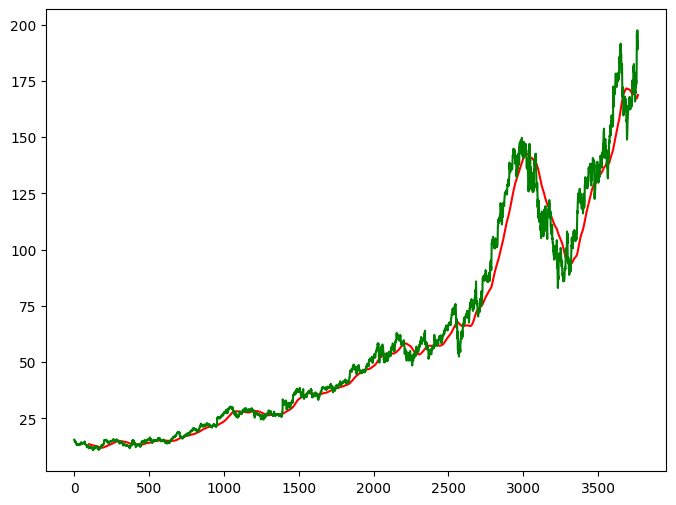

In [38]:
plt.figure(figsize=(8,6))
plt.plot(mav_100,'r')
plt.plot(data.Close,'g')
plt.show()

In [39]:
mav_200 =data.Close.rolling(200).mean()


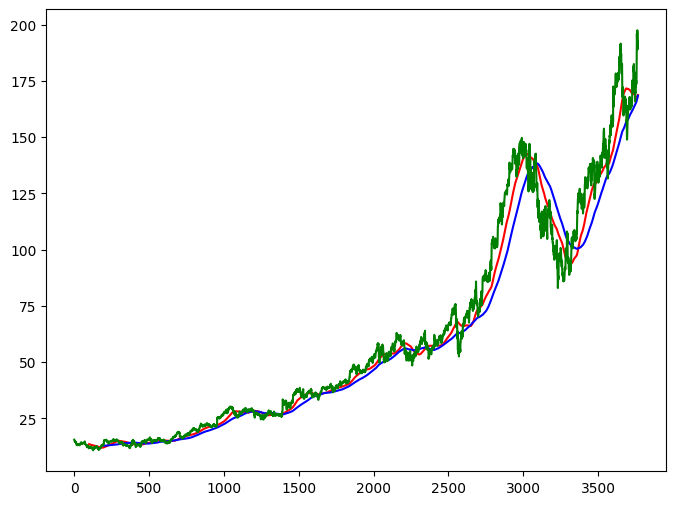

In [40]:
plt.figure(figsize=(8,6))
plt.plot(mav_100,'r')
plt.plot(mav_200,'b')
plt.plot(data.Close,'g')
plt.show()

In [42]:
data_train = pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80):len(data)])
print('Train shape',data_train.shape)
print('Test shape',data_test.shape)

Train shape (3014, 1)
Test shape (754, 1)


In [66]:
data_train

Ticker,GOOG
0,15.504141
1,15.435865
2,15.046745
3,14.696465
4,14.892385
...,...
3009,146.366867
3010,143.854080
3011,141.832397
3012,141.433655


In [67]:
data_test

Ticker,GOOG
0,135.065216
1,135.353729
2,135.103958
3,136.009262
4,136.104584
...,...
949,197.520325
950,196.483673
951,189.536179
952,189.087631


we are going to fit the actual stock price into 0 and 1

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_trainScale = scaler.fit_transform(data_train)

In [68]:
data_trainScale

array([[0.03395974],
       [0.03346819],
       [0.03066669],
       ...,
       [0.94346718],
       [0.94059641],
       [0.95360331]], shape=(3014, 1))

In [47]:
x=[]
y=[]
for i in range(100,data_trainScale.shape[0]):
    x.append(data_trainScale[i-100:i])
    y.append(data_trainScale[i,0])

x,y=np.array(x),np.array(y)

In [48]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [50]:
model = Sequential()
model.add(LSTM(units=50,activation='relu', return_sequences=True,input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [52]:
model.fit(x,y,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - loss: 0.0145
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 189ms/step - loss: 0.0047
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - loss: 0.0041
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - loss: 0.0028
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - loss: 0.0030
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - loss: 0.0026
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - loss: 0.0024
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 194ms/step - loss: 0.0025
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 184ms/step - loss: 0.0025
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0020
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - loss: 0.0022
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - loss: 0.0020
Epoch 13/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 172ms/step - loss: 0.0018
Epoch 14/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - loss: 0.0019
Epoch 15/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 

In [53]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [80]:
pas_100 = data_train.tail(100)
data_test = pd.concat([pas_100,data_test],ignore_index=True)

data_testScale = scaler.transform(data_test)

In [89]:
x=[]
y=[]
for i in range(100,data_testScale.shape[0]):
    x.append(data_testScale[i-100:i])
    y.append(data_testScale[i,0])

x,y=np.array(x),np.array(y)

In [90]:
y_pred = model.predict(x)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


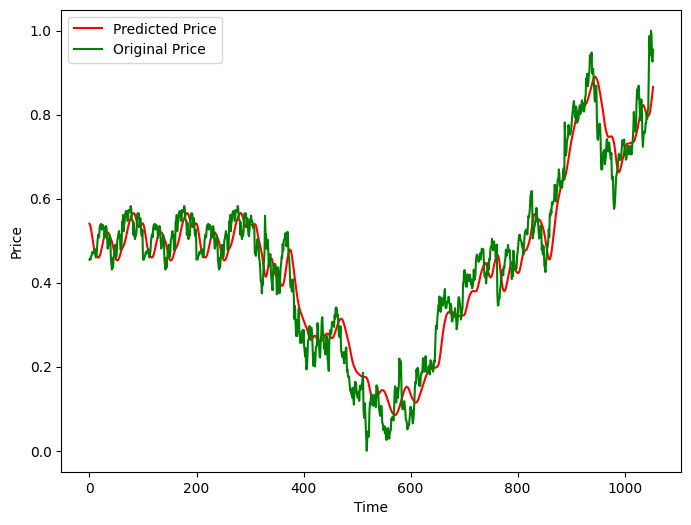

In [91]:
plt.figure(figsize=(8,6))
plt.plot(y_pred,'r',label = 'Predicted Price')
plt.plot(y,'g',label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [92]:
model.save('Stock_prediction_model.keras')